<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/UBER_ANALYSIS_TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA ANALYSIS ON REAL-TIME DATASET (UBER ANALYSIS)

## IMPORT ALL NECESSARY LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("https://github.com/Taj1920/Data_Analysis/raw/refs/heads/main/Uber_Analysis/UberDataset.csv")
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


## DATA EXPLORATION

In [3]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1154 non-null   object 
 2   CATEGORY    1154 non-null   object 
 3   START       1154 non-null   object 
 4   STOP        1154 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     652 non-null    object 
dtypes: float64(1), object(6)
memory usage: 72.2+ KB


In [4]:
df.isnull().sum()

,0
START_DATE,0
END_DATE,1
CATEGORY,1
START,1
STOP,1
MILES,0
PURPOSE,503


## HANDLING MISSING VALUES AND NULL VALUES

In [5]:
df['START_DATE'].unique()
df['END_DATE'].unique()
df['START_DATE']=pd.to_datetime(df['START_DATE'],errors='coerce')
df['END_DATE']=pd.to_datetime(df['END_DATE'],errors='coerce')
df['END_DATE']=df['END_DATE'].fillna(method='ffill')
df['END_DATE'].isnull().sum()
df['START_DATE'].isnull().sum()

/tmp/ipykernel_480/2286491302.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['END_DATE']=df['END_DATE'].fillna(method='ffill')


np.int64(734)

In [6]:
df['CATEGORY'].unique()
mode=df['CATEGORY'].mode()[0]
df['CATEGORY'].fillna(mode,inplace=True)
df['CATEGORY'].unique()
df['CATEGORY'].isnull().sum()

/tmp/ipykernel_480/3817150710.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CATEGORY'].fillna(mode,inplace=True)


np.int64(0)

In [7]:
df['START'].unique()
mode=df['START'].mode()[0]
df['START'].fillna(mode,inplace=True)
df['START'].isnull().sum()

/tmp/ipykernel_480/4076149758.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['START'].fillna(mode,inplace=True)


np.int64(0)

In [8]:
df['START']=df['START'].str.replace("Kar?chi","Karachi")
df['STOP']=df['STOP'].str.replace("Kar?chi","Karachi")

In [9]:
df['STOP'].unique()
mode=df['STOP'].mode()[0]
df['STOP'].fillna(mode,inplace=True)
df['STOP'].isnull().sum()

/tmp/ipykernel_480/4125939708.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['STOP'].fillna(mode,inplace=True)


np.int64(0)

In [16]:
df['START_DATE']=pd.to_datetime(df['START_DATE'])
df['START_DATE']=df['START_DATE'].fillna("2016-01-16")
df['START_DATE'].isnull().sum()

np.int64(0)

In [17]:
df['PURPOSE'].unique()
df['PURPOSE']=df['PURPOSE'].fillna("Personal")
df.isnull().sum()

,0
START_DATE,0
END_DATE,0
CATEGORY,0
START,0
STOP,0
MILES,0
PURPOSE,0


## FEATURE ENGINEERING

In [18]:
df['MONTH']=[i.month for i in df['START_DATE']]
df['MONTH']=df['MONTH'].map({1:'JAN',  2:'FEB',  3:'MAR',  4:'APR',  5:'MAY',  6:'JUN',  7:'JUL',  8:'AUG',  9:'SEP', 10:'OCT', 11:'NOV', 12:'DEC'})
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,MONTH
0,2016-01-01,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,JAN
1,2016-01-02,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Personal,JAN
2,2016-01-02,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,JAN
3,2016-01-05,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,JAN
4,2016-01-06,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,JAN
...,...,...,...,...,...,...,...,...
1151,2016-01-16,2016-12-12 20:57:00,Business,Karachi,Unknown Location,3.9,Temporary Site,JAN
1152,2016-01-16,2016-12-12 20:57:00,Business,Unknown Location,Unknown Location,16.2,Meeting,JAN
1153,2016-01-16,2016-12-12 20:57:00,Business,Katunayake,Gampaha,6.4,Temporary Site,JAN
1154,2016-01-16,2016-12-12 20:57:00,Business,Gampaha,Ilukwatta,48.2,Temporary Site,JAN


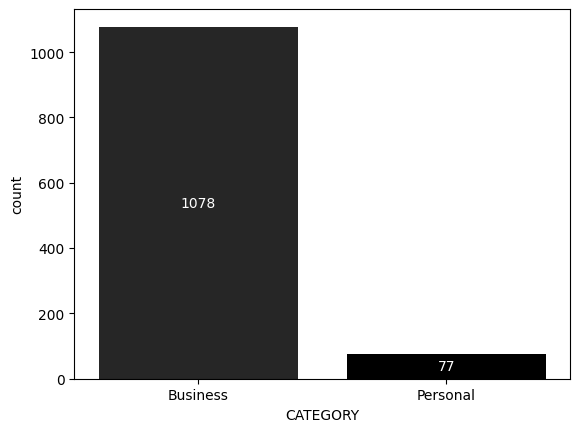

In [19]:
ax = sns.countplot(x='CATEGORY', data=df, hue='CATEGORY', palette='dark:black')
# Add labels directly
for container in ax.containers:
    ax.bar_label(container, label_type='center', color='white')
plt.show()

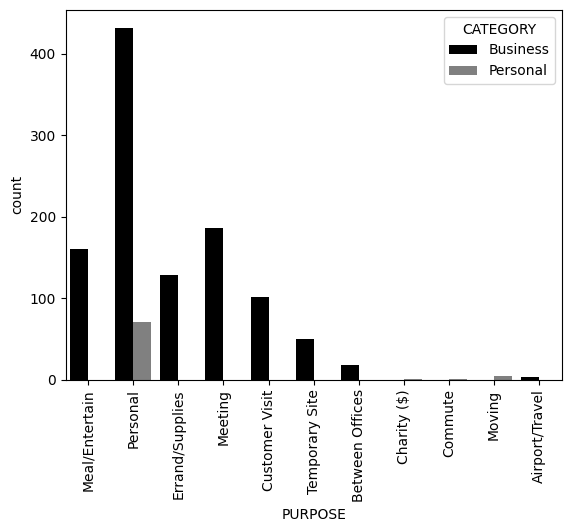

In [20]:
uber_palette = sns.color_palette(["black","gray"])
a=sns.countplot(x='PURPOSE',data=df,hue='CATEGORY',palette=uber_palette)
plt.xticks(rotation=90)
plt.show()

## counting which business category is more ,
## mostly personal, followed by meeting are more


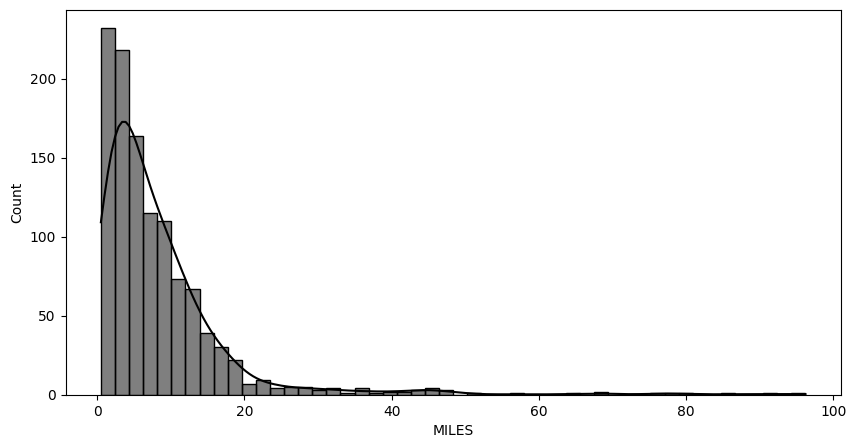

In [21]:
##
plt.figure(figsize=(10,5))
sns.histplot(x='MILES',data=df[df['MILES']<100],kde=True,bins=50,color='black')
plt.show()


## right skewed: mostly 0-20 miles people travel by uber